Name - Pranav Upadhyaya

Dataset source: https://www.kaggle.com/datasets/jahnavipaliwal/customer-feedback-and-satisfaction 

Github link - https://github.com/pranav-upd/ai-programming-foundations-project

Dataset Info:
The Customer Feedback and Satisfaction Dataset is a synthetic dataset designed to analyze and predict customer satisfaction based on various demographic and behavioral factors. It contains data for 38,444 customers, capturing their feedback on products and services in a structured format.

Description:
We will be cleaning and pre-processing this 38,444 customer dataset on the customer feedback and satisfaction. We will then be performing explorartory data analysis on the pre-processed data and report our findings in this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cf_dataset.csv")
df.head()

,CustomerID,Age,Gender,Country,Income,ProductQuality,ServiceQuality,PurchaseFrequency,FeedbackScore,LoyaltyLevel,SatisfactionScore
0,1,56,Male,UK,83094,5,8,5,Low,Bronze,100.0
1,2,69,Male,UK,86860,10,2,8,Medium,Gold,100.0
2,3,46,Female,USA,60173,8,10,18,Medium,Silver,100.0
3,4,32,Female,UK,73884,7,10,16,Low,Gold,100.0
4,5,60,Male,UK,97546,6,4,13,Low,Bronze,82.0


Age should be int

Satisfaction score should be numeric

Categories should be either object or category

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38444 entries, 0 to 38443
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         38444 non-null  int64  
 1   Age                38444 non-null  int64  
 2   Gender             38444 non-null  str    
 3   Country            38444 non-null  str    
 4   Income             38444 non-null  int64  
 5   ProductQuality     38444 non-null  int64  
 6   ServiceQuality     38444 non-null  int64  
 7   PurchaseFrequency  38444 non-null  int64  
 8   FeedbackScore      38444 non-null  str    
 9   LoyaltyLevel       38444 non-null  str    
 10  SatisfactionScore  38444 non-null  float64
dtypes: float64(1), int64(6), str(4)
memory usage: 3.2 MB


**Pre EDA data processing**

In [ ]:
def remove_duplicates_and_missing(df):
    """
    Removes duplicate rows and handles missing values in the dataset.

    Parameters:
    df (pandas.DataFrame): The input DataFrame to be cleaned.

    Returns:
    pandas.DataFrame: A cleaned DataFrame with duplicates removed and missing values handled.
    
    Notes:
    - Duplicate rows are dropped using drop_duplicates().
    - Rows with missing values are removed using dropna().
    - This approach is suitable for datasets with minimal missing data.
    """
    
    df_cleaned = df.drop_duplicates()
    df_cleaned = df_cleaned.dropna()
    
    return df_cleaned

 **Data Cleaning Step: Removing Duplicates and Missing Values**

A preliminary audit of the dataset showed that there were no missing values and no duplicate rows. However, this step was included as a safeguard to ensure data quality and reproducibility of the workflow.

Removing duplicates is a standard best practice to prevent repeated records from biasing analysis results. Similarly, handling missing values ensures that statistical summaries and visualizations are not distorted.

Since the dataset is synthetic and already clean, this step did not remove any rows but confirms that the dataset is reliable for further analysis.

 **Data Validation Step: Age Range Check**

The Age variable was examined to ensure values fall within a realistic human age range. The dataset showed values between 18 and 69, which are valid and do not require filtering.

A condition such as Age < 100 is often used as a safeguard against unrealistic outliers (e.g., data entry errors). In this dataset, no such outliers were found, so no rows were removed.

In [ ]:
def standardize_categories(df):
    """
    Standardizes categorical string columns by converting text to lowercase 
    and removing leading/trailing whitespace.

    Parameters:
    df (pandas.DataFrame): The input DataFrame with categorical columns.

    Returns:
    pandas.DataFrame: DataFrame with standardized categorical values.
    
    Notes:
    - Applies only to columns with dtype 'object' or 'string'.
    - Ensures consistency (e.g., 'Male', 'male', ' MALE ' → 'male').
    """
    
    categorical_cols = df.select_dtypes(include=['object', 'string']).columns
    
    for col in categorical_cols:
        df[col] = df[col].str.strip().str.lower()
    
    return df

**Data Cleaning Step: Standardizing Categorical Values**

Categorical columns such as Gender, Country, FeedbackScore, and LoyaltyLevel were converted to lowercase and stripped of whitespace.

This step ensures consistency in categorical values. For example, in real-world datasets, values like "Male", "male", and " MALE " may appear as separate categories, which can lead to incorrect groupings and misleading results.

Although this dataset did not show major inconsistencies during inspection, standardizing categories is a preventive measure to ensure robustness and consistency in analysis.

In [4]:
df = remove_duplicates_and_missing(df)
df = standardize_categories(df)

**Initial Data Audit**

Before cleaning, the dataset was evaluated for common data quality issues including missing values, duplicates, inconsistent categorical values, and outliers.

The audit revealed:
  1) No missing values
  2) No duplicate rows
  3) Consistent categorical values
  4) Valid ranges for numerical features

Based on this, only minimal cleaning and standardization steps were applied.

**EDA Functions**

Exploratory Data Analysis (EDA) was conducted using custom functions to evaluate dataset structure, summary statistics, grouped insights, and feature correlations. These functions enabled efficient and repeatable analysis of the dataset.”

In [5]:
def eda_summary(df):
    print("🔹 Dataset Shape:")
    print(df.shape)
    
    print("\n🔹 Data Types:")
    print(df.dtypes)
    
    print("\n🔹 Missing Values:")
    print(df.isnull().sum())
    
    print("\n🔹 Summary Statistics (Numerical):")
    print(df.describe())
    
    print("\n🔹 Summary Statistics (Categorical):")
    print(df.describe(include=['object', 'string']))

In [6]:
def eda_correlation(df):
    corr = df.corr(numeric_only=True)
    
    print("\n🔹 Correlation Matrix:")
    print(corr)
    
    return corr

**Combined EDA Function**

In [7]:
def run_full_eda(df):
    print("===== EDA SUMMARY =====")
    eda_summary(df)
    
    print("\n===== CORRELATION CHECK =====")
    eda_correlation(df)

In [8]:
# Usage
run_full_eda(df)

===== EDA SUMMARY =====
🔹 Dataset Shape:
(38444, 11)

🔹 Data Types:
CustomerID             int64
Age                    int64
Gender                   str
Country                  str
Income                 int64
ProductQuality         int64
ServiceQuality         int64
PurchaseFrequency      int64
FeedbackScore            str
LoyaltyLevel             str
SatisfactionScore    float64
dtype: object

🔹 Missing Values:
CustomerID           0
Age                  0
Gender               0
Country              0
Income               0
ProductQuality       0
ServiceQuality       0
PurchaseFrequency    0
FeedbackScore        0
LoyaltyLevel         0
SatisfactionScore    0
dtype: int64

🔹 Summary Statistics (Numerical):
         CustomerID           Age         Income  ProductQuality  \
count  38444.000000  38444.000000   38444.000000    38444.000000   
mean   19222.500000     43.496853   75076.619238        5.494746   
std    11097.971211     14.972748   25975.752966        2.873192   
min    

**1. Satisfaction Score Distribution**

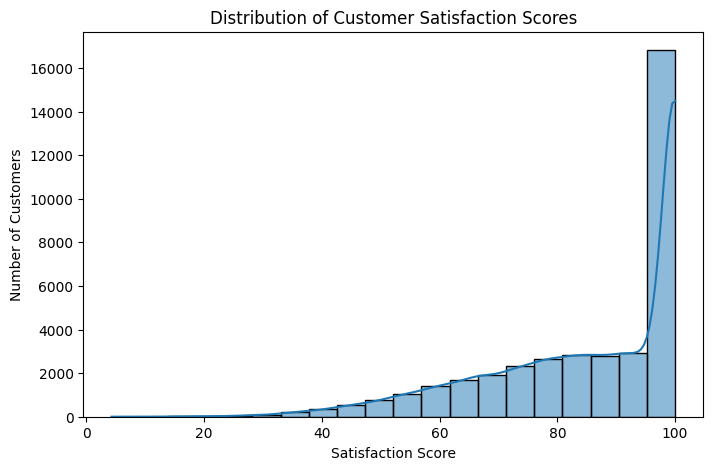

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['SatisfactionScore'], bins=20, kde=True)

plt.title('Distribution of Customer Satisfaction Scores')
plt.xlabel('Satisfaction Score')
plt.ylabel('Number of Customers')

plt.show()

**2. Satisfaction vs Age (Relationship)**

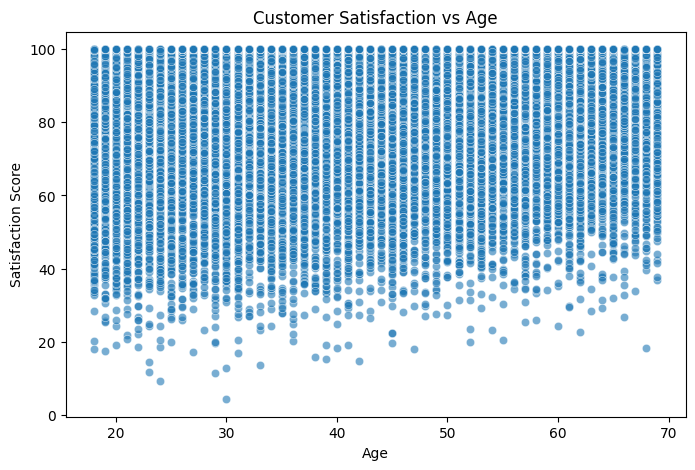

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='SatisfactionScore', data=df, alpha=0.6)

plt.title('Customer Satisfaction vs Age')
plt.xlabel('Age')
plt.ylabel('Satisfaction Score')

plt.show()

**3. Average Satisfaction by Gender (Categorical Insight)**

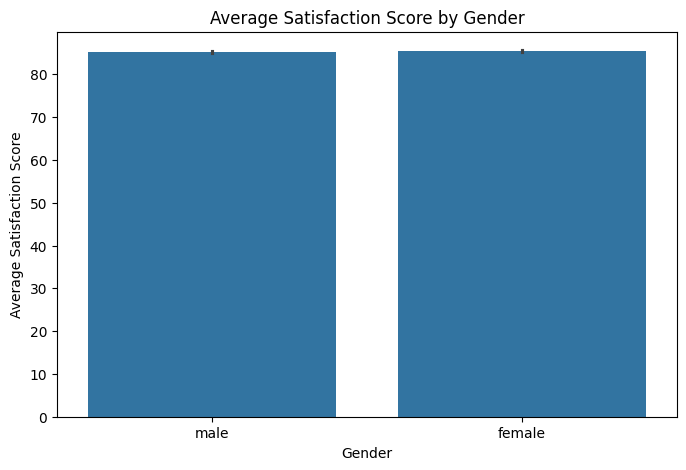

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(x='Gender', y='SatisfactionScore', data=df)

plt.title('Average Satisfaction Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Satisfaction Score')

plt.show()

**What I Learned from the Dataset**

The dataset is well-structured and clean, with no missing values or major inconsistencies.

Customer satisfaction is influenced more by experience factors (product & service quality) than by demographics.

The customer base is diverse and balanced across age, gender, and geography.

Behavioral metrics like purchase frequency exist, but they are not strong drivers of satisfaction.

**Interesting Patterns / Insights**

*Strongest drivers of satisfaction*:

Product Quality (~0.55 correlation)
Service Quality (~0.55 correlation)

These are the most impactful variables.

*Moderate influence*:

Income (~0.24)
Age (~0.16)

Suggests slightly higher satisfaction among older and higher-income customers.

*Weak relationship*:

Purchase Frequency (~0.11)

Surprisingly, frequent customers are not necessarily more satisfied.

*Ratings distribution*:

Product & service quality average ~5.5/10
Satisfaction average ~85/100

Indicates customers may still report high satisfaction despite moderate ratings.

**Limitations / Assumptions**

*Synthetic dataset*:

Patterns may not reflect real-world customer behavior
Relationships could be artificially constructed
Limited features

*No data on*:

Customer complaints

Time-based behavior (trends over time)

Specific product categories

No causal inference

Correlation ≠ causation

We cannot say quality causes satisfaction, only that they are related

*Categorical simplification*:

FeedbackScore and LoyaltyLevel have only 3 levels → may oversimplify real behavior

**Anything Surprising or Unclear**

High satisfaction despite average quality scores

Product/Service ratings ~5.5, but satisfaction ~85

*Suggests*:

Different scales OR

Satisfaction influenced by other hidden factors

Weak link between purchase frequency and satisfaction

*Could indicate*:

Habitual buying

Lack of alternatives

*Very clean dataset*:

No missing values or noise

Unrealistic for real-world data, reinforcing that it’s synthetic